In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import pandas as pd

In [2]:
df = pd.read_csv('data_logistic_reg.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TT                    129880 non-null  int64  
 1   Danh_Gia              129880 non-null  object 
 2   Chat_Luong_Tai_Xe     129880 non-null  int64  
 3   Thoi_Gian_vs_Du_Kien  129487 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.0+ MB


In [3]:
df.dropna(inplace=True)
df.isnull().sum()

,0
TT,0
Danh_Gia,0
Chat_Luong_Tai_Xe,0
Thoi_Gian_vs_Du_Kien,0


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Danh_Gia'] = le.fit_transform(df['Danh_Gia'])
df['Danh_Gia'].head()
df['Danh_Gia'].unique()
df['Danh_Gia'].value_counts()

,count
Danh_Gia,
1,70882
0,58605


In [8]:
X = df[['Chat_Luong_Tai_Xe', 'Thoi_Gian_vs_Du_Kien']]
y = df['Danh_Gia']
print(X.shape)
print(y.shape)

(129487, 2)
(129487,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
print(f'Number of tests: {len(y_test)}')

Number of tests: 25898


In [10]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8028805313151595
Precision: 0.8149764477694652
Recall: 0.8285794774279879
F1 Score: 0.821721669285839


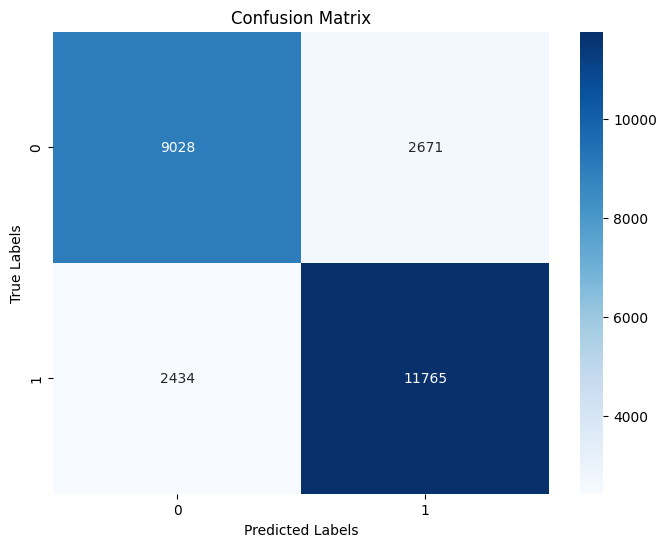

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
df = pd.read_csv('data_decision_tree_bt.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127282 entries, 0 to 127281
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   TT                       127282 non-null  int64  
 1   DoHaiLong                127282 non-null  object 
 2   LoaiKhachHang            127282 non-null  object 
 3   Tuoi                     127282 non-null  int64  
 4   LoaiHinh                 127282 non-null  object 
 5   DoTrePhut                126894 non-null  float64
 6   GheNgoi                  127282 non-null  int64  
 7   ThucAn                   127282 non-null  int64  
 8   GateLocation             127282 non-null  int64  
 9   DichVuGuiXe              127282 non-null  int64  
 10  BauKhongKhiTranDau       127282 non-null  int64  
 11  ChatLuongTranDau         127282 non-null  int64  
 12  TraiNghiemDatVeOnline    127282 non-null  int64  
 13  ChatLuongCacDichVuDiKem  127282 non-null  int64  
 14  DoAn

In [15]:
df.isnull().sum()

,0
TT,0
DoHaiLong,0
LoaiKhachHang,0
Tuoi,0
LoaiHinh,0
DoTrePhut,388
GheNgoi,0
ThucAn,0
GateLocation,0
DichVuGuiXe,0


In [16]:
df.dropna(inplace=True)
df.isnull().sum()

,0
TT,0
DoHaiLong,0
LoaiKhachHang,0
Tuoi,0
LoaiHinh,0
DoTrePhut,0
GheNgoi,0
ThucAn,0
GateLocation,0
DichVuGuiXe,0


In [19]:
print(df['LoaiHinh'].unique())
print(df['LoaiKhachHang'].unique())
print(df['DoHaiLong'].unique())

['Đi Cùng Gia Đình/Bạn Bè' 'Đi Cá Nhân']
['KH Bình Thường' 'KH Trung Thành']
['Không Hài Lòng' 'Hài Lòng']


In [22]:
df.head()

,TT,DoHaiLong,LoaiKhachHang,Tuoi,LoaiHinh,DoTrePhut,GheNgoi,ThucAn,GateLocation,DichVuGuiXe,BauKhongKhiTranDau,ChatLuongTranDau,TraiNghiemDatVeOnline,ChatLuongCacDichVuDiKem,DoAnToan,ThoiTiet,SuSachSe,FanDoiNha,ThietKeLoiDi
0,0,Không Hài Lòng,KH Bình Thường,29,Đi Cùng Gia Đình/Bạn Bè,15.0,5,5,4,5,2,5,1,5,5,4,5,4,5
1,1,Không Hài Lòng,KH Trung Thành,44,Đi Cùng Gia Đình/Bạn Bè,0.0,4,5,5,3,1,4,3,4,3,3,2,3,5
2,2,Hài Lòng,KH Trung Thành,48,Đi Cùng Gia Đình/Bạn Bè,0.0,5,2,1,4,2,5,4,5,4,4,4,4,3
3,3,Hài Lòng,KH Bình Thường,45,Đi Cùng Gia Đình/Bạn Bè,0.0,5,5,4,3,2,4,3,5,5,5,5,5,3
4,4,Không Hài Lòng,KH Trung Thành,49,Đi Cá Nhân,0.0,4,4,2,4,1,5,4,5,4,1,4,2,4


In [21]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
df_encoded.head()

,TT,Tuoi,DoTrePhut,GheNgoi,ThucAn,GateLocation,DichVuGuiXe,BauKhongKhiTranDau,ChatLuongTranDau,TraiNghiemDatVeOnline,ChatLuongCacDichVuDiKem,DoAnToan,ThoiTiet,SuSachSe,FanDoiNha,ThietKeLoiDi,DoHaiLong_Không Hài Lòng,LoaiKhachHang_KH Trung Thành,LoaiHinh_Đi Cùng Gia Đình/Bạn Bè
0,0,29,15.0,5,5,4,5,2,5,1,5,5,4,5,4,5,1,0,1
1,1,44,0.0,4,5,5,3,1,4,3,4,3,3,2,3,5,1,1,1
2,2,48,0.0,5,2,1,4,2,5,4,5,4,4,4,4,3,0,1,1
3,3,45,0.0,5,5,4,3,2,4,3,5,5,5,5,5,3,0,0,1
4,4,49,0.0,4,4,2,4,1,5,4,5,4,1,4,2,4,1,1,0


In [23]:
df_encoded = df_encoded.rename(columns={
  'LoaiHinh_Đi Cùng Gia Đình/Bạn Bè': 'LoaiHinh',
  'LoaiKhachHang_KH Trung Thành': 'LoaiKhachHang',
  'DoHaiLong_Không Hài Lòng': 'DoHaiLong'
})

In [24]:
df_encoded.head()

,TT,Tuoi,DoTrePhut,GheNgoi,ThucAn,GateLocation,DichVuGuiXe,BauKhongKhiTranDau,ChatLuongTranDau,TraiNghiemDatVeOnline,ChatLuongCacDichVuDiKem,DoAnToan,ThoiTiet,SuSachSe,FanDoiNha,ThietKeLoiDi,DoHaiLong,LoaiKhachHang,LoaiHinh
0,0,29,15.0,5,5,4,5,2,5,1,5,5,4,5,4,5,1,0,1
1,1,44,0.0,4,5,5,3,1,4,3,4,3,3,2,3,5,1,1,1
2,2,48,0.0,5,2,1,4,2,5,4,5,4,4,4,4,3,0,1,1
3,3,45,0.0,5,5,4,3,2,4,3,5,5,5,5,5,3,0,0,1
4,4,49,0.0,4,4,2,4,1,5,4,5,4,1,4,2,4,1,1,0


In [25]:
y = df_encoded['DoHaiLong']
X = df_encoded.drop(columns=['DoHaiLong', 'TT'])
print(X.shape, y.shape)

(126894, 17) (126894,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
model = DecisionTreeClassifier(random_state=10)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=10)

In [27]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Accuracy: 0.89
Precision: 0.88
Recall: 0.88
F1 Score: 0.88


In [35]:
print(f'Tree depth: {model.get_depth()}')
print(f'Tree leaves: {model.get_n_leaves()}')

Tree depth: 36
Tree leaves: 9918


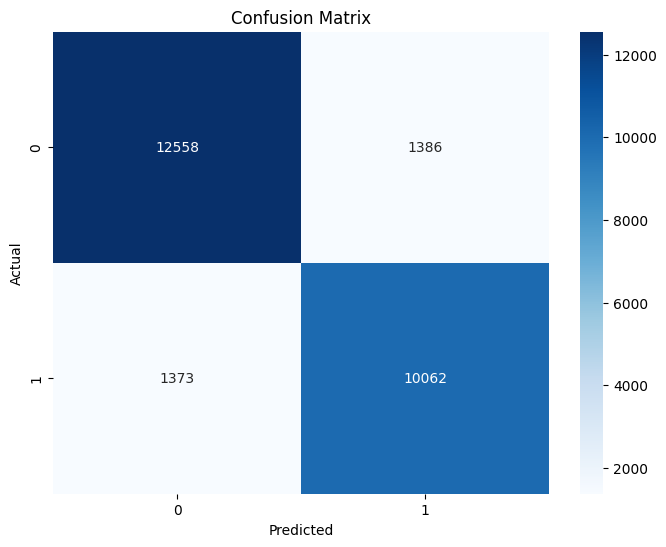

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

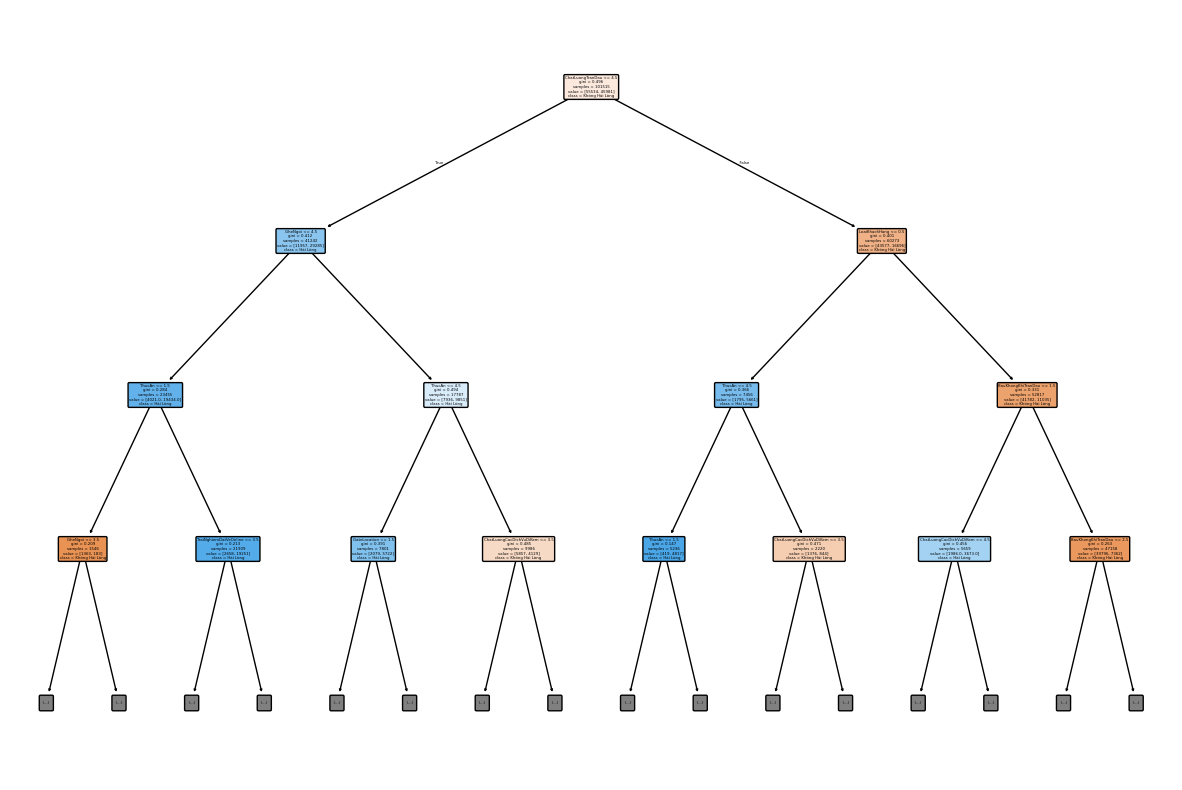

In [31]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['Không Hài Lòng', 'Hài Lòng'], rounded=True, max_depth=3)
plt.show()


In [32]:
X_test_10 = X_test.iloc[:10]
pred_10 = model.predict(X_test_10)
print(pred_10)
print(y_test.iloc[:10].values)

[0 1 0 0 0 0 1 1 0 0]
[0 1 0 0 0 0 1 1 0 0]


In [37]:
model2 = DecisionTreeClassifier(random_state=10, max_depth=10, min_samples_split=10, min_samples_leaf=5)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2)
cm2 = confusion_matrix(y_test, y_pred2)

In [38]:
print(f"Accuracy: {accuracy2:.2f}")
print(f"Precision: {precision2:.2f}")
print(f"Recall: {recall2:.2f}")
print(f"F1 Score: {f12:.2f}")

Accuracy: 0.89
Precision: 0.90
Recall: 0.86
F1 Score: 0.88


In [36]:
print(f'Tree depth: {model2.get_depth()}')
print(f'Tree leaves: {model2.get_n_leaves()}')

Tree depth: 5
Tree leaves: 31


In [39]:
import joblib

joblib.dump(model2, 'my_model.joblib')

['my_model.joblib']

In [3]:
import joblib
model2 = joblib.load('my_model.joblib')
print(f'Tree depth: {model2.get_depth()}')
print(f'Tree leaves: {model2.get_n_leaves()}')

Tree depth: 10
Tree leaves: 606
